<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c8_ex12_ex13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train a Gaussian mixture model on the Olivetti faces dataset. To speed up the algorithm, you should probably reduce the dataset's dimensionality (e.g., use PCA, preserving 99% of the variance). Use the model to generate new faces using the `sample()` method and visualize them (if you used PCA you will need to use its `inverse_transform()` method). Try to modify some images (e.g. rotate, flip, darken) and see if the model can detect the anomalies (i.e. compare the the output of `score_sample()` for normal images vs. anomalies).

In [1]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [2]:
from sklearn.model_selection import train_test_split
X = faces.data  # shape is (400, 4069)
y = faces.target  # the labels

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: split temporary into validation and test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_  # 256 which is quite less than 4096

np.int64(222)

In [5]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=42)
gm.fit(X_train_pca)

GaussianMixture(n_components=40, random_state=42)

In [6]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

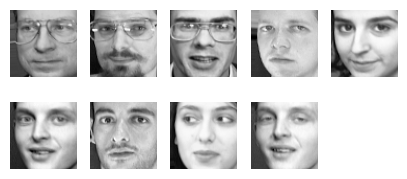

In [17]:
# Now, for fun, let's plot one of the clusters.

labels = gm.predict(X_train_pca) #hard clustering

cluster = 15

cluster_faces = X_train[labels == cluster]

plot_faces(cluster_faces[:20], labels=[""] * min(20, len(cluster_faces)))



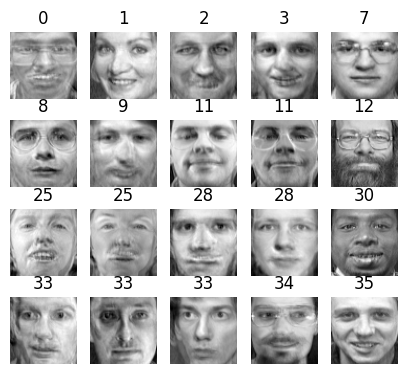

In [18]:
X_new, y_new = gm.sample(20) #sample method samples new instances in this Gaussian Mixture
X_new = pca.inverse_transform(X_new) #inverse of PCA
plot_faces(X_new, y_new)

Try to modify some images (e.g. rotate, flip, darken) and see if the model can detect the anomalies (i.e. compare the the output of `score_sample()` for normal images vs. anomalies).

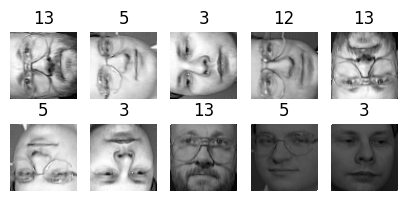

In [10]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

In [12]:
X_bad_faces_pca = pca.transform(X_bad_faces)
gm.score_samples(X_bad_faces_pca)

array([-33568280.74134503, -35803390.27107028, -23522792.62773432,
       -45063230.11379728, -35022991.99442962, -30322006.61397303,
       -27625911.24563251, -65931575.61269509, -47040006.56065232,
       -54819107.47626887])

In [13]:
# these are all very small numbers. Compare with 10 images in the training set:
# we obtain much larger numbers, that is, the model recognizes anomalies.
gm.score_samples(X_train_pca[:10])

array([1300.88105588, 1285.53282097, 1151.21825652, 1260.78843316,
       1271.10341678, 1146.32308582, 1227.33322317, 1263.01087665,
       1300.61719535, 1300.67593848])

Exercise 13. Some dimensionality reduction techniques can also be used for anomaly detection. For example, take the Olivetti faces dataset and reduce it with PCA, preserving 99% of the variance. Then compute the reconstruction error for each image. Next, take some of the modified images you built in the previous exercise, and look at their reconstruction error: notice how much larger the reconstruction error is. If you plot a reconstructed image, you will see why: it tries to reconstruct a normal face.

In [21]:
# We have already reduced the training set: X_train_pca
# the reconstrucion error is the mean square distance between
# the original instance and the inverse of the pca-reduced instance
X_reconstructed = pca.inverse_transform(X_train_pca)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(X_train, X_reconstructed)

mse

0.0001899989292724058

Suppose:

$$
m = 320
$$

is the number of training images, and

$$
n = 4096
$$

is the number of pixels per image.

Then`mean_squared_error(X_train, X_reconstructed` computes

$$
\frac{1}{mn}\sum_{i=1}^{m}\sum_{j=1}^{n}
\left(X_{ij}-\hat X_{ij}\right)^2.
$$



Equivalently,

$$
\frac{1}{m}\sum_{i=1}^{m}
\left(
\frac{1}{n}\sum_{j=1}^{n}
(X_{ij}-\hat X_{ij})^2
\right),
$$
and
$$
e_i= \frac{1}{n}\sum_{j=1}^{n}
(X_{ij}-\hat X_{ij})^2
$$
is precisely the reconstruction error of the $i$-th instance.
Therefore `mean_squared_error(X_train, X_reconstructed` finds the mean
$$
\frac{1}{m}\sum_{i=1}^{m}
e_i
$$
of the reconstruction errors of all the instances.


In [22]:
X_bad_reconstructed = pca.inverse_transform(X_bad_faces_pca)
mse_bad = mean_squared_error(X_bad_faces, X_bad_reconstructed)
mse_bad

0.004373969044536352

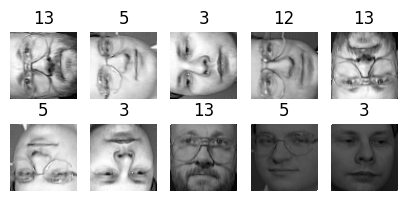

In [24]:
plot_faces(X_bad_faces, y_bad)

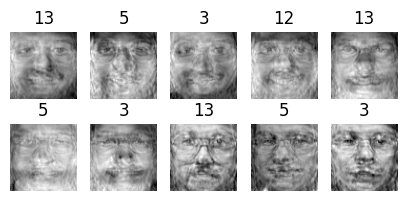

In [25]:
plot_faces(X_bad_reconstructed, y_bad)